# K-Nearest Neighbors (KNN) Regression

K-Nearest Neighbors Regression is a supervised machine learning
algorithm used to predict continuous numerical values.

Instead of learning a mathematical equation, KNN makes predictions
based on the nearest training observations.

Basic idea:

New Data Point
      ↓
Find K nearest observations
      ↓
Take their target values
      ↓
Calculate their average
      ↓
Prediction

## How KNN Regression Works

Suppose K = 3.

For a new data point:

1. Calculate the distance between the new point and training points.
2. Find the 3 nearest points.
3. Take their target values.
4. Calculate their average.
5. Use the average as the prediction.

Example:

Nearest target values:

10
12
14

Prediction:

(10 + 12 + 14) / 3 = 12

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [30]:
df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [31]:
df.shape

(244, 7)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [33]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [34]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## Features and Target

We will predict:

Target:
- tip

Features:
- total_bill
- size

Therefore:

total_bill + size
       ↓
KNN Regressor
       ↓
tip

In [35]:
X = df[
    [
        "total_bill",
        "size"
    ]
]

y = df["tip"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   total_bill  size
0       16.99     2
1       10.34     3
2       21.01     3
3       23.68     2
4       24.59     4

Target:
0    1.01
1    1.66
2    3.50
3    3.31
4    3.61
Name: tip, dtype: float64


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (195, 2)
Testing: (49, 2)


## Why Feature Scaling is Important for KNN

KNN uses distance to find neighboring observations.

For example:

Feature 1 → values between 10 and 100

Feature 2 → values between 1,000 and 100,000

The larger-scale feature can dominate the distance calculation.

Therefore, feature scaling is very important for KNN.

We will use StandardScaler.

In [37]:
knn_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        KNeighborsRegressor(n_neighbors=5)
    )
])

In [38]:
knn_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['total_bill','size']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [39]:
y_pred = knn_pipeline.predict(
    X_test
)

y_pred[:10]

array([3.142, 1.91 , 3.682, 3.906, 1.866, 3.036, 2.728, 1.86 , 2.454,
       1.946])

In [40]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,3.18,3.142
1,2.00,1.910
2,2.00,3.682
3,5.16,3.906
4,2.00,1.866
5,2.00,3.036
6,2.56,2.728
7,2.52,1.860
8,3.23,2.454
9,3.00,1.946


## Mean Absolute Error

MAE measures the average absolute difference between actual and
predicted values.

Lower MAE means better predictions.

In [41]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 0.6751020408163265


## Root Mean Squared Error (RMSE)

RMSE is the square root of Mean Squared Error.

Formula:

RMSE = √MSE

RMSE measures how far the model's predictions are from the actual
values.

Unlike MSE, RMSE is expressed in the same unit as the target variable.

For example, if we are predicting tip in dollars, RMSE is also measured
in dollars.

Lower RMSE generally indicates better model performance.

In [42]:
mse = mean_squared_error(
    y_test,
    y_pred
)

In [43]:
import numpy as np
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.8170382550432271


In [44]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R² Score:", r2)

R² Score: 0.4659465493119843


In [45]:
print("KNN Regression Performance")
print("--------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

KNN Regression Performance
--------------------------
MAE : 0.6751020408163265
MSE : 0.6675515102040815
RMSE: 0.8170382550432271
R²  : 0.4659465493119843


## Understanding K

The `n_neighbors` parameter determines how many neighboring points
are used to make a prediction.

Small K:

K = 1

The prediction depends on only one nearest observation.

This can make the model sensitive to noise.

Large K:

K = 50

The prediction uses many observations.

This produces smoother predictions but can make the model too simple.

Therefore, K should be selected carefully.

In [46]:
k_values = range(1, 21)

results = []

for k in k_values:

    pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            KNeighborsRegressor(
                n_neighbors=k
            )
        )
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    y_pred_k = pipeline.predict(
        X_test
    )

    rmse_k = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred_k
        )
    )

    r2_k = r2_score(
        y_test,
        y_pred_k
    )

    results.append({
        "K": k,
        "RMSE": rmse_k,
        "R2": r2_k
    })

results_df = pd.DataFrame(results)

results_df

,K,RMSE,R2
0,1,0.967439,0.251232
1,2,0.901557,0.349741
2,3,0.819048,0.463316
3,4,0.853720,0.416917
4,5,0.817038,0.465947
5,6,0.847079,0.425953
6,7,0.868830,0.396093
7,8,0.871066,0.392982
8,9,0.846494,0.426745
9,10,0.851386,0.420100


In [47]:
best_k = results_df.loc[
    results_df["RMSE"].idxmin(),
    "K"
]

print("Best K:", best_k)

Best K: 19


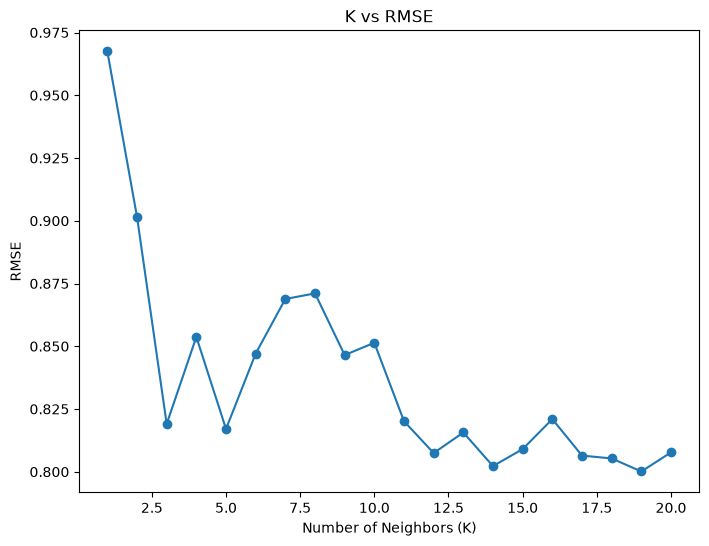

In [48]:
plt.figure(figsize=(8, 6))

plt.plot(
    results_df["K"],
    results_df["RMSE"],
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("RMSE")
plt.title("K vs RMSE")

plt.show()

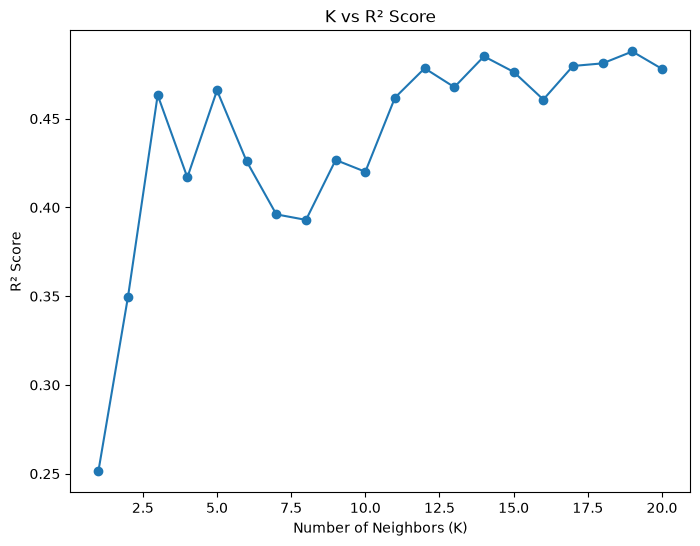

In [49]:
plt.figure(figsize=(8, 6))

plt.plot(
    results_df["K"],
    results_df["R2"],
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("R² Score")
plt.title("K vs R² Score")

plt.show()

In [50]:
best_knn = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        KNeighborsRegressor(
            n_neighbors=int(best_k)
        )
    )
])

best_knn.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['total_bill','size']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [51]:
best_pred = best_knn.predict(
    X_test
)

best_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_pred
    )
)

best_r2 = r2_score(
    y_test,
    best_pred
)

print("Best K:", best_k)
print("RMSE:", best_rmse)
print("R²:", best_r2)

Best K: 19
RMSE: 0.8001001831103228
R²: 0.4878600174042721


In [52]:
new_data = pd.DataFrame({
    "total_bill": [50],
    "size": [3]
})

prediction = best_knn.predict(
    new_data
)

print("Predicted Tip:", prediction[0])

Predicted Tip: 4.715263157894737


## Advantages of KNN Regression

- Simple and easy to understand.
- No complex mathematical equation is required.
- Can model non-linear relationships.
- Very little training is required.
- Works well for smaller datasets.

## Disadvantages of KNN Regression

- Prediction can be computationally expensive for large datasets.
- Sensitive to feature scaling.
- Sensitive to the choice of K.
- Sensitive to irrelevant features.
- Sensitive to outliers.
- Requires storing the training data.